In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 設定中文字體，解決中文顯示問題
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']  # 設定字體
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

In [8]:
# 1. 設定目標：台積電
stock_id = "2330.TW"
print(f"正在從雲端下載 {stock_id} 的資料... (請稍等)")

# 建立 Ticker 物件 (這是 yfinance 的核心)
stock = yf.Ticker(stock_id)

正在從雲端下載 2330.TW 的資料... (請稍等)


In [9]:
# --- A. 抓取股價 (技術面資料) ---
# period="5y" 代表抓過去 5 年，interval="1d" 代表日線
df_price = stock.history(period="5y", interval="1d")

print(f"\n--- {stock_id} 近 5 年股價資料 ---")
print(df_price.tail()) # 印出最後 5 天看看


--- 2330.TW 近 5 年股價資料 ---
                             Open    High     Low   Close    Volume  \
Date                                                                  
2026-01-19 00:00:00+08:00  1725.0  1780.0  1725.0  1760.0  29580038   
2026-01-20 00:00:00+08:00  1740.0  1775.0  1740.0  1775.0  29401234   
2026-01-21 00:00:00+08:00  1745.0  1765.0  1740.0  1740.0  45192749   
2026-01-22 00:00:00+08:00  1765.0  1770.0  1750.0  1760.0  32069478   
2026-01-23 00:00:00+08:00  1770.0  1775.0  1750.0  1770.0  27601167   

                           Dividends  Stock Splits  
Date                                                
2026-01-19 00:00:00+08:00        0.0           0.0  
2026-01-20 00:00:00+08:00        0.0           0.0  
2026-01-21 00:00:00+08:00        0.0           0.0  
2026-01-22 00:00:00+08:00        0.0           0.0  
2026-01-23 00:00:00+08:00        0.0           0.0  


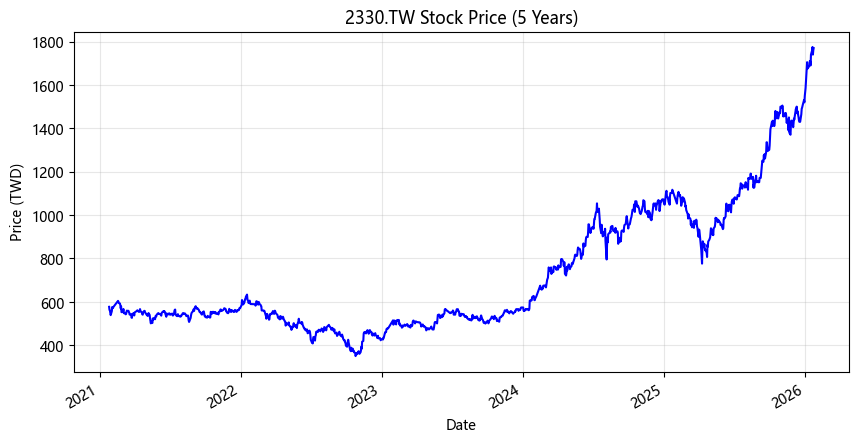

In [10]:
# 簡單畫個圖確認一下
plt.figure(figsize=(10, 5))
df_price['Close'].plot(title=f"{stock_id} Stock Price (5 Years)", color='blue')
plt.ylabel('Price (TWD)')
plt.grid(True, alpha=0.3)
# plt.savefig('real_stock_price.png')
plt.show()

In [11]:
# --- B. 抓取財報 (基本面資料) ---
# 這些資料就是我們算 Piotroski F-Score 需要的原料
print(f"\n--- {stock_id} 年度資產負債表 (部分) ---")
# balance_sheet: 資產負債表
# financials: 損益表
# cashflow: 現金流量表

# 我們只看最近 3 年的資料 (.iloc[:, :3])
# 這是 DataFrame 格式，您可以直接用 Data Wrangler 開啟觀察！
balance_sheet = stock.balance_sheet.iloc[:, :3]
income_stmt = stock.financials.iloc[:, :3]
cash_flow = stock.cashflow.iloc[:, :3]


--- 2330.TW 年度資產負債表 (部分) ---


In [12]:
# 試著印出幾個關鍵會計科目
try:
    print(f"現金 (Cash): \n{balance_sheet.loc['Cash And Cash Equivalents']}")
    print("-" * 30)
    print(f"淨利 (Net Income): \n{income_stmt.loc['Net Income']}")
except KeyError:
    print("注意：Yahoo Finance 的會計科目名稱有時候會變，需要檢查欄位名稱。")

print("\n任務完成！真實資料已入手。")

現金 (Cash): 
2024-12-31    2.127627e+12
2023-12-31    1.465428e+12
2022-12-31    1.342814e+12
Name: Cash And Cash Equivalents, dtype: float64
------------------------------
淨利 (Net Income): 
2024-12-31    1.158380e+12
2023-12-31    8.517400e+11
2022-12-31    9.929234e+11
Name: Net Income, dtype: float64

任務完成！真實資料已入手。
